<a href="https://colab.research.google.com/github/csk01/lpg-cylinder-detection/blob/main/lpg_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

# imports
!pip install roboflow ultralytics -q
from google.colab import files
from google.colab import userdata
from roboflow import Roboflow




In [8]:
#uploading best.pt
uploaded = files.upload()

Saving best.pt to best (2).pt


In [11]:
roboflow_api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(roboflow_api_key)
project = rf.workspace("krishnans-workspace-eu0zb").project("lpg-identification-v2")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to LPG-Identification-v2-2 in yolov11:: 100%|██████████| 1417/1417 [00:00<00:00, 7359.81it/s]


In [12]:
# Cell 4 — generate crops
from ultralytics import YOLO
model = YOLO("best.pt")
results = model(
    f"{dataset.location}/train/images/",
    conf=0.6,
    save_crop=True,
    project="lpg-crops",
    name="v1"
)
print("Crops done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/495 /content/LPG-Identification-v2-2/train/images/bharatgas_0001_jpg.rf.9d52729c7d5eb79a257b6bc710a89d45.jpg: 640x640 1 lpg-cylinder, 475.8ms
image 2/495 /content/LPG-Identification-v2-2/train/images/bharatgas_0005_jpg.rf.93844ae7195730b286d40876bdf4ae54.jpg: 640x640 1 lpg-cylinder, 271.6ms
image 3/495 /content/LPG-Identification-v2-2/train/images/bharatgas_0007_jpg.rf.717122096f7dfc178da8398d993175e4.jpg: 640x640 1 lpg-cylinder, 213.8ms
image 4/495 /content/LPG-Identification-v2-2/train/images/bharatgas_0010_jpg.rf.33b8d46e45e5fcae6db50f9ed5716e77.jpg: 640x640 1 lpg-cylinder, 355.4ms
image 5/495 /content/LPG-Identification-v2-2/train/images/bharatgas_0011_jpg.rf.af9c6bfd

In [13]:
import os
crops_dir = "/content/runs/detect/lpg-crops/v1/crops/lpg-cylinder"
files = os.listdir(crops_dir)
print(f"Total crops: {len(files)}")
print("Sample files:")
for f in files[:10]:
    print(f)

Total crops: 703
Sample files:
indane_0189_jpg.jpg
bharatgas_0163_jpg3.jpg
other_lpg_0007_webp3.jpg
bharatgas_0091_jpeg.jpg
hpgas_0011_jpeg.jpg
indane_0388_jpeg2.jpg
indane_0094_jpeg2.jpg
hpgas_0149_jpg.jpg
bharatgas_0120_jpeg.jpg
hpgas_0270_jpg.jpg


In [14]:
from PIL import Image
import shutil

output_dir = "/content/classification_crops"
os.makedirs(output_dir, exist_ok=True)

kept = 0
skipped = 0

for img_file in os.listdir(crops_dir):
    img_path = os.path.join(crops_dir, img_file)
    try:
        img = Image.open(img_path)
        w, h = img.size
        if w > 80 and h > 80:
            shutil.copy(img_path, output_dir)
            kept += 1
        else:
            skipped += 1
    except:
        skipped += 1

print(f"✅ Kept: {kept}")
print(f"❌ Skipped: {skipped}")

✅ Kept: 690
❌ Skipped: 13


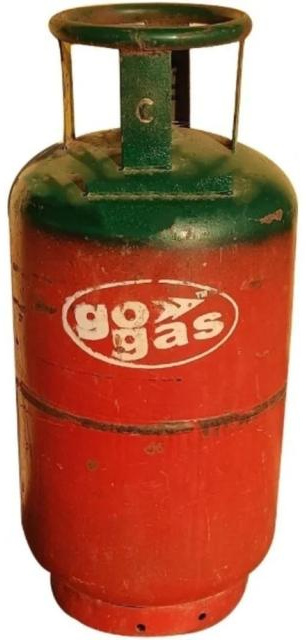

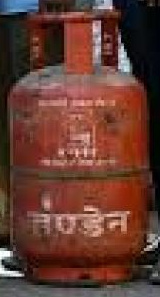

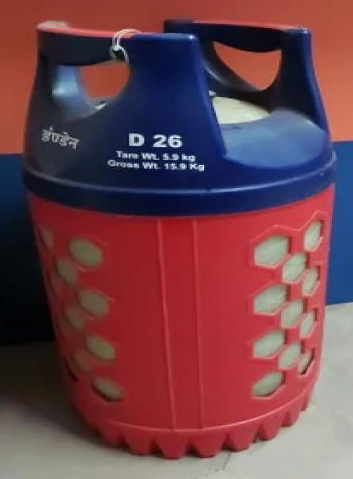

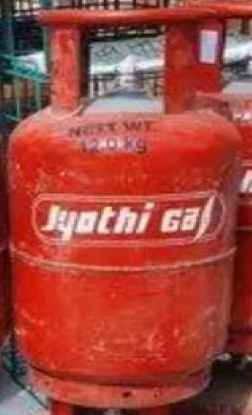

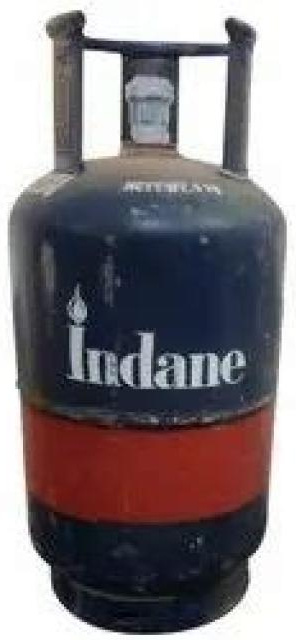

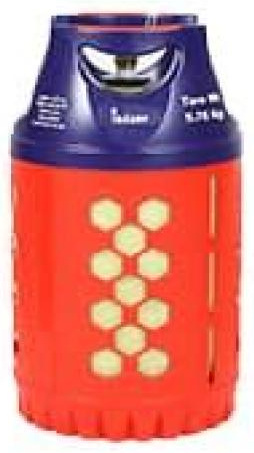

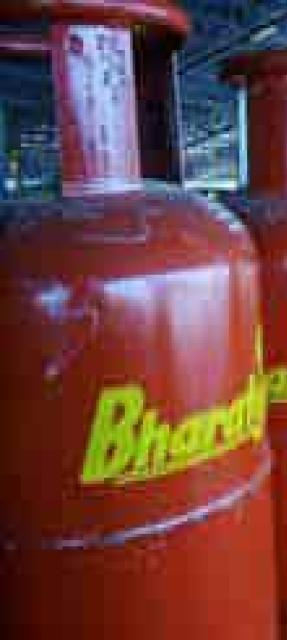

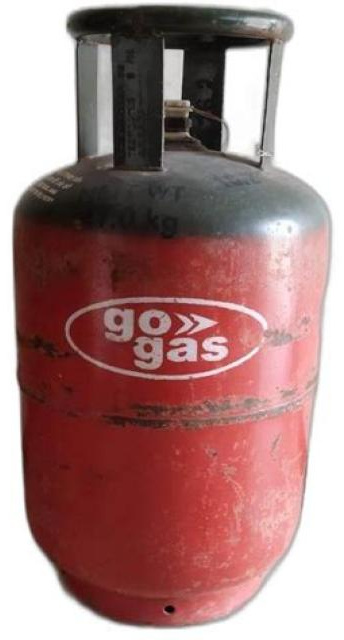

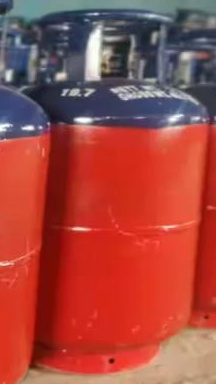

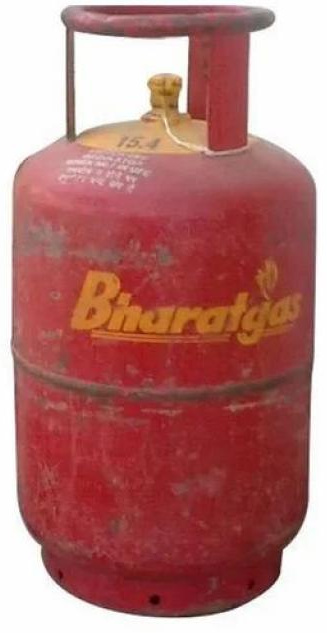

In [15]:
from IPython.display import display
from PIL import Image
import random

samples = random.sample(os.listdir(output_dir), min(10, len(os.listdir(output_dir))))
for s in samples:
    img = Image.open(os.path.join(output_dir, s))
    display(img)

In [16]:
for brand in ["indane", "bharat_gas", "hp_gas", "unknown"]:
    os.makedirs(f"/content/classification_crops/{brand}", exist_ok=True)
print("Folders created!")

Folders created!


In [17]:
import shutil
shutil.make_archive("/content/crops_to_sort", 'zip', "/content/classification_crops")

from google.colab import files
files.download("/content/crops_to_sort.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>